<a href="https://colab.research.google.com/github/Ingjk/Programacion-para-Analitica-de-Datos/blob/main/Analisis_de_Ventas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Análisis de ventas**
## ======= **1. Importar librerías de Python  ========**

In [129]:
import pandas as pd             # Pandas: libreria para procesamiento, manipulación y análisis de datos <br>
import matplotlib.pyplot as plt # librería especializada en la creación de visualizaciones estáticas, animadas e interactivas.
import matplotlib.ticker as ticker
import seaborn as sns           # Seaborn: librería ideal para visualización de datos estadísticos


## ======= **2. Lectura y carge de datos ========**

In [130]:
#leer archivo en formato .csv
df = pd.read_csv('ventas_tienda_local.csv')

## ======= **3. Análisis exploratorio de datos  =========** <br>
este proceso permite "conocer" o "hacerse una idea" del contenido del DataFrame

In [131]:
# df.info() brinda un resumen mostrando los nombres de las columnas, sus tipos de datos,
# la cantidad de valores no nulos y la memoria total utilizada por la estructura de datos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Venta         1240 non-null   object 
 1   Fecha            1240 non-null   object 
 2   Categoría        1225 non-null   object 
 3   Producto         1240 non-null   object 
 4   Cantidad         1210 non-null   float64
 5   Precio_Unitario  1215 non-null   float64
 6   Total_Venta      1185 non-null   float64
dtypes: float64(3), object(4)
memory usage: 67.9+ KB


In [132]:
df.describe()
#Resumen estadístico: el método df.describe() de la biblioteca Pandas genera un resumen estadístico de las columnas numéricas.
# Calcula valores clave como el conteo, media, desviación estándar, valores mínimos/máximos y los cuartiles (25%, 50%, 75%),
#ofreciendo una visión rápida de la dispersión y distribución de los datos


,Cantidad,Precio_Unitario,Total_Venta
count,1210.000000,1.215000e+03,1.185000e+03
mean,3.003306,8.438189e+04,2.927443e+05
std,1.525083,6.395184e+05,2.576413e+06
min,-4.000000,5.000000e+03,-1.400000e+05
25%,2.000000,1.500000e+04,3.600000e+04
50%,3.000000,2.800000e+04,7.500000e+04
75%,4.000000,4.000000e+04,1.400000e+05
max,5.000000,9.999999e+06,5.000000e+07


**Conclusión sobre identificación de valores atípicos extremos (outliers/errores de digitación)** se observa que el el máximo de Precio_Unitario es 9'999.999 10 millones, y el maximo  de Total_Venta es 50'000.000 (50 millones)_. Sin embargo, el percentil 75% del precio es de apenas 40.000. Esto significa que el 75% o más de tus productos valen menos de $40.000 pesos, pero hay un error masivo de digitación (un "ruido") de 10 millones que está inflando y distorsionando completamente tu promedio real de ventas.

In [133]:
df.head()
# permite Visualizar las primera filas. En Python, el método df.head() de la librería Pandas
# permite visualizar las primeras filas de un DataFrame (Por defecto, devuelve las primeras 5 filas)

,ID_Venta,Fecha,Categoría,Producto,Cantidad,Precio_Unitario,Total_Venta
0,V-1000,2025-11-24,Electrónica,Teclado Mecánico,3.0,45000.0,135000.0
1,V-1001,2025-05-06,Ropa,Jeans Slim Fit,1.0,35000.0,35000.0
2,V-1002,2025-12-13,Deportes,Mancuernas 5kg,5.0,25000.0,125000.0
3,V-1003,2025-08-05,Electrónica,Teclado Mecánico,1.0,45000.0,45000.0
4,V-1004,2025-04-22,Ropa,Medias Deportivas,5.0,5000.0,25000.0


In [134]:
df.sample(10)
# se usa para visualizar filas al azar mediante el método df.sample(10)
# de Pandas en Python selecciona filas al azar del DataFrame (en este caso 10 filas).

,ID_Venta,Fecha,Categoría,Producto,Cantidad,Precio_Unitario,Total_Venta
600,V-1600,2025-09-02,Hogar,Cafetera Expreso,1.0,120000.0,120000.0
354,V-1354,2025-11-04,Hogar,Juego de Sábanas,1.0,40000.0,40000.0
634,V-1634,2025-06-27,Ropa,Chaqueta de Invierno,2.0,75000.0,150000.0
803,V-1803,2025-06-15,Hogar,Juego de Sábanas,5.0,40000.0,200000.0
767,V-1767,2025-11-11,Ropa,Sudadera,5.0,28000.0,140000.0
311,V-1311,2025-03-01,Ropa,Camiseta Algodón,1.0,12000.0,12000.0
921,V-1921,2025-11-11,Deportes,Cuerda para Saltar,2.0,8000.0,16000.0
136,V-1136,2025-12-02,Electrónica,Teclado Mecánico,4.0,45000.0,180000.0
595,V-1595,2025-08-23,Hogar,Cafetera Expreso,1.0,NaN,NaN
575,V-1575,2025-06-26,Ropa,Chaqueta de Invierno,1.0,75000.0,75000.0


In [135]:
##Contar la cantidad y el pocentaje de nulos:
# mediante  df.isnull().sum() y df.isnull().sum() / len(df)) * 100
df.isnull().sum()
valores_nulos = pd.DataFrame({
    'Nulos Totales': df.isnull().sum(),
    'Porcentaje %': (df.isnull().sum() / len(df)) * 100
})
print(valores_nulos)

                 Nulos Totales  Porcentaje %
ID_Venta                     0      0.000000
Fecha                        0      0.000000
Categoría                   15      1.209677
Producto                     0      0.000000
Cantidad                    30      2.419355
Precio_Unitario             25      2.016129
Total_Venta                 55      4.435484


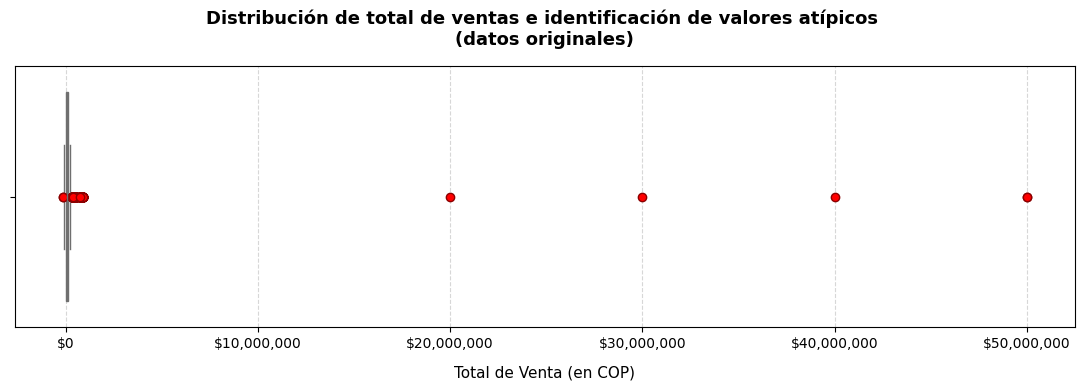

In [136]:
# Crear grafico de caja y bigotes (o box plot) para visualizar los valres atipicos
fig, ax = plt.subplots(figsize=(11, 4))

sns.boxplot(
    x=df['Total_Venta'].dropna(),
    ax=ax,
    color='skyblue',
    flierprops=dict(marker='o', markerfacecolor='red', markersize=6, markeredgecolor='darkred')
)

# Títulos y formato
ax.set_title('Distribución de total de ventas e identificación de valores atípicos \n(datos originales)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Total de Venta (en COP)', fontsize=11, labelpad=10)

# Formateador de moneda
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x:,.0f}'))
ax.grid(True, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

**Conclusión del gráfico de caja y bigotes.** mientras las mayoria de los datos se aplilan a la parte izquiersa de la grafica, existe un valor atipico en las venats por 49'999.995
 los cual fue generado por una venat con valor unitario de 9'999.999 lo cual debemos interpreatr como un error de digitación


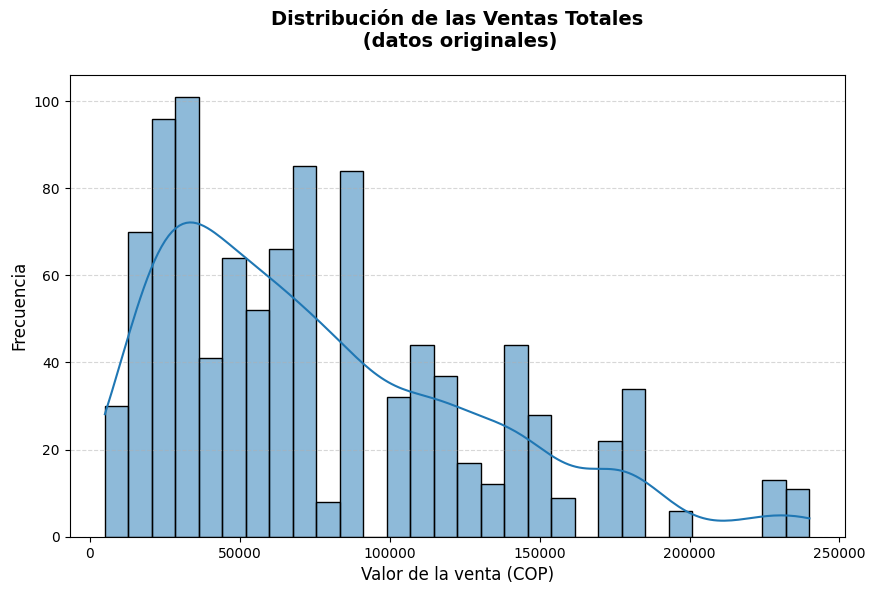

In [162]:
# Histograma ventas totales
ig, ax = plt.subplots(figsize=(10,6))

sns.histplot(df['Total_Venta'], bins=30, kde=True, ax=ax)

ax.set_title(
    "Distribución de las Ventas Totales\n (datos originales)",
    fontsize=14,
    fontweight='bold',
    pad=20
)

ax.set_xlabel("Valor de la venta (COP)", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)

ax.grid(axis='y', linestyle='--', alpha=0.5)

fig.tight_layout()
fig.subplots_adjust(top=0.90)

plt.show()

**Grafico lineas de Ventas por fecha**

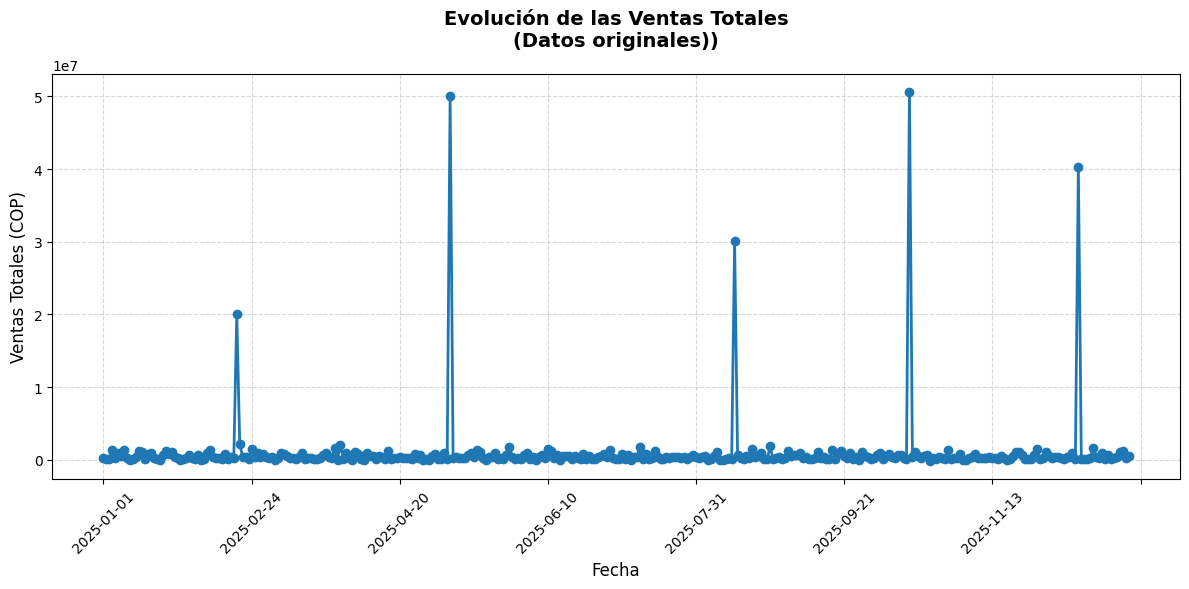

In [138]:
# Agrupar las ventas por fecha
ventas = df.groupby('Fecha')['Total_Venta'].sum()

# Crear la figura
plt.figure(figsize=(12,6))

# Graficar la evolución de las ventas
ventas.plot(marker='o', linewidth=2)

# Título del gráfico
plt.title(
    "Evolución de las Ventas Totales\n(Datos originales))",
    fontsize=14,
    fontweight='bold',
    pad=20
)

# Títulos de los ejes
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Ventas Totales (COP)", fontsize=12)

# Mejorar la visualización
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

# Ajustar márgenes
plt.tight_layout()

plt.show()

**Grafico de Barras de distribución por categoria**

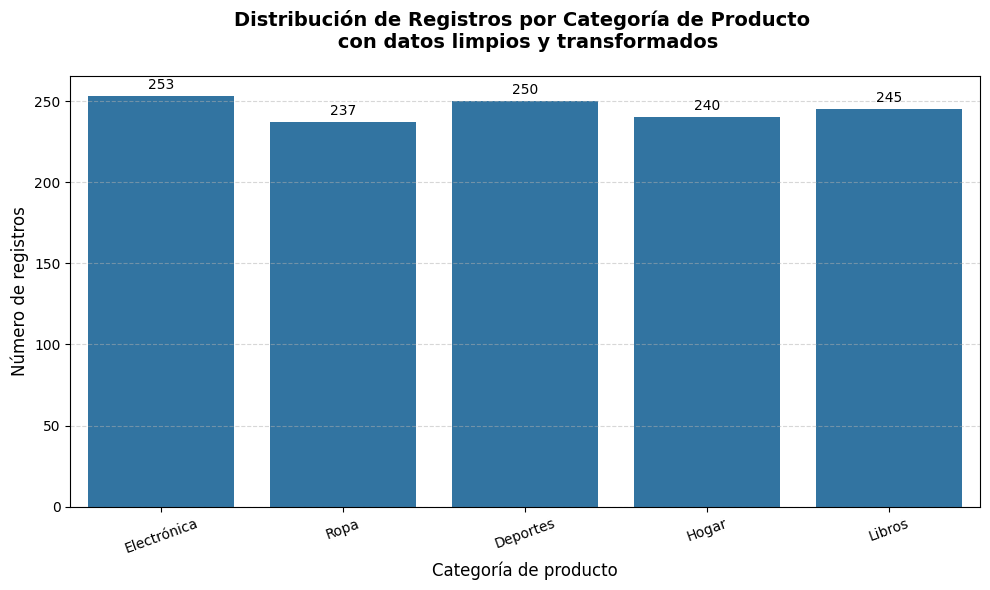

In [139]:
# Gráfico de barras de la distribución por categoría
plt.figure(figsize=(10, 6))

# Asignamos el gráfico a la variable 'ax'
ax = sns.countplot(data=df, x='Categoría')

plt.title(
    "Distribución de Registros por Categoría de Producto \n con datos limpios y transformados",
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.xlabel("Categoría de producto", fontsize=12)
plt.ylabel("Número de registros", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=20)

# --- NUEVA LÍNEA: Coloca los valores sobre las barras ---
# padding=3 separa un poco el texto de la barra, fmt='%d' asegura que sean números enteros
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fmt='%d')

plt.tight_layout()
plt.show()

##========= **4. Limpieza y transformación de datos** =========

In [140]:
# eliminar valores nulos
df = df.dropna(subset=['Categoría', 'Cantidad', 'Precio_Unitario'])

In [141]:
#verificar que los valroes nulso fueron eliminados
df.isna().sum()

,0
ID_Venta,0
Fecha,0
Categoría,0
Producto,0
Cantidad,0
Precio_Unitario,0
Total_Venta,0


In [142]:
# verificar la existencia de valores duplicados
df.duplicated().sum()

np.int64(37)

In [143]:
# eliminar valores duplicados
df=df.drop_duplicates()

In [144]:
#vololvemos a verificar los duplicados para comprobar que fueron eliminados
df.duplicated().sum()

np.int64(0)

In [145]:
# vericamos si hay valores negativos en las columnas numericos
cantidad_negativos = (df.select_dtypes(include='number') < 0).sum()
print(cantidad_negativos)

Cantidad           10
Precio_Unitario     0
Total_Venta        10
dtype: int64


**Observación sobre valores negativos:** Se debe señalar que en operaciones contables una cantidad negativa puede representar una devolución de mercancía o un error de digitación. Para este ejercicio los valores negativos se interpretaran como errores de digitación; Por lo tanto, se procederá a convertir los valores negativos a positivos con **_.abs()_** y se consideran como una venta y no como una devolución.

In [146]:
# para las columnas Cantidad y Total_Venta que contienen valores nulos se corrige su valor a numero positivo
if df[df['Cantidad']<0].shape[0]>0:
  df['Cantidad'] = df['Cantidad'].abs()
if df[df['Total_Venta']<0].shape[0]>0:
  df['Total_Venta'] = df['Total_Venta'].abs()

In [147]:
#Verificamos que los valores negativos se convirtieron a numeros positivos (no hay negativos)
cantidad_negativos = (df.select_dtypes(include='number') < 0).sum()
print(cantidad_negativos)

Cantidad           0
Precio_Unitario    0
Total_Venta        0
dtype: int64


In [148]:
# Convertir la columna Fecha a tipo fecha
df['Fecha'] = pd.to_datetime(df['Fecha'])

**Aplicar validación de consistencia de datos:** este tipo de verificación se utiliza para comprobar que los valores almacenados cumplen una regla de negocio.

In [149]:
#Desemos saber si en cada fila el valor total de la venta es el producto de las cantidades por el valor de cada unidad
# Calcular el total esperado
df['Total_Calculado'] = df['Cantidad'] * df['Precio_Unitario']

# Validar cada registro
df['Validación'] = df['Total_Venta'] == df['Total_Calculado']

# Contar registros válidos e inválidos
print(df['Validación'].value_counts())

# Mostrar únicamente los registros inconsistentes
df[df['Validación'] == False]

Validación
True    1133
Name: count, dtype: int64


,ID_Venta,Fecha,Categoría,Producto,Cantidad,Precio_Unitario,Total_Venta,Total_Calculado,Validación


**Observación:** para este caso el resultado obtenido al aplicar validación de consistencia de datos significa que el conjunto de datos pasó completamente la validación de consistencia.

**Detectar y eliminar valores atípicos (outliers)** en la columna Total_Venta de un DataFrame (df). Específicamente, aplica el método del Rango Intercuartílico (IQR), que es un estándar estadístico para limpiar datos atípicos por arriba de lo normal

In [150]:
# Calcular los cuartiles
Q1 = df['Total_Venta'].quantile(0.25)
Q3 = df['Total_Venta'].quantile(0.75)

# Calcular el rango intercuartílico
IQR = Q3 - Q1

# Definir límites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Cantidad de registros antes de la limpieza
registros_iniciales = len(df)

# Eliminar valores atípicos
df = df[
    (df['Total_Venta'] >= limite_inferior) &
    (df['Total_Venta'] <= limite_superior)
]

# Cantidad de registros eliminados
registros_finales = len(df)
registros_eliminados = registros_iniciales - registros_finales

print(f"Límite inferior: {limite_inferior:,.2f}")
print(f"Límite superior: {limite_superior:,.2f}")
print(f"Registros eliminados: {registros_eliminados}")

Límite inferior: -120,000.00
Límite superior: 296,000.00
Registros eliminados: 127


## ===== **5.  Análisis estadístico y visualización de datos limpios y transformados** =====



### **==== 5.1 Medidas estadisticas ==**

In [151]:
# medidas estadisticas basicas
total_ventas = df['Total_Venta'].sum()
promedio_ventas = df['Total_Venta'].mean()
venta_maxima = df['Total_Venta'].max()
venta_minima = df['Total_Venta'].min()

print("Medidas estadisticas basicas\n")

print(f"Suma total de ventas: ${total_ventas:,.2f}") # obtiene el total de las ventas
print(f"Promedio de ventas: ${promedio_ventas:,.2f}") # obtiene el promedio de las ventas
print(f"Venta máxima: ${venta_maxima:,.2f}")# obtiene la venta maxima
print(f"Venta mínima: ${venta_minima:,.2f}") # obtiene la venta minima

Medidas estadisticas basicas

Suma total de ventas: $78,055,000.00
Promedio de ventas: $77,589.46
Venta máxima: $240,000.00
Venta mínima: $5,000.00


In [152]:
#obtener ventas por categoria
# nos permite rresponder, por ejemplo, ¿qué categoría genera mayores ingresos?
ventas_categoria = (
    df.groupby('Categoría')['Total_Venta']
      .sum()
      .sort_values(ascending=False)
)
print("Informe de ventas por categoria\n")
print(ventas_categoria.map('${:,.2f}'.format))

Informe de ventas por categoria

Categoría
Electrónica    $17,925,000.00
Hogar          $17,524,000.00
Ropa           $15,720,000.00
Deportes       $13,737,000.00
Libros         $13,149,000.00
Name: Total_Venta, dtype: object


In [153]:
#Cantidad vendida por categoria
# Util para responder a preguntas como ¿qué categoría vende más unidades?
cantidad_categoria = (
    df.groupby('Categoría')['Cantidad']
      .sum()
      .sort_values(ascending=False)
)
print ("Total de unidades vendidas por categoria\n")
print (cantidad_categoria)

Total de unidades vendidas por categoria

Categoría
Deportes       716.0
Libros         696.0
Ropa           609.0
Electrónica    505.0
Hogar          440.0
Name: Cantidad, dtype: float64


In [154]:
precio_promedio = (
    df.groupby('Categoría')['Precio_Unitario']
      .mean()
)

print("Precio promedio por categoria\n")
# Aplicar formato con separador de miles y 2 decimales
print(precio_promedio.map('${:,.2f}'.format))

Precio promedio por categoria

Categoría
Deportes       $19,429.79
Electrónica    $41,740.33
Hogar          $51,822.78
Libros         $18,964.91
Ropa           $28,519.61
Name: Precio_Unitario, dtype: object


In [155]:
# Obtener ventas mensuales
ventas_mes = (
    df.groupby(df['Fecha'].dt.to_period('M'))['Total_Venta']
      .sum()
)
print("Ventas mensuales\n")
# Aplicamos formato de moneda con signo de peso y dos decimales
print(ventas_mes.map('${:,.2f}'.format))

Ventas mensuales

Fecha
2025-01    $4,978,000.00
2025-02    $6,672,000.00
2025-03    $5,529,000.00
2025-04    $5,089,000.00
2025-05    $8,588,000.00
2025-06    $8,609,000.00
2025-07    $6,909,000.00
2025-08    $6,107,000.00
2025-09    $4,390,000.00
2025-10    $6,400,000.00
2025-11    $6,927,000.00
2025-12    $7,857,000.00
Freq: M, Name: Total_Venta, dtype: object


In [156]:
# Obteenr los días con mayores ventas
dias_mayor_Ventas = (
    df.groupby('Fecha')['Total_Venta']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)
print (dias_mayor_Ventas.map('${:,.2f}'.format))

Fecha
2025-12-02    $1,075,000.00
2025-07-14      $781,000.00
2025-11-02      $774,000.00
2025-10-11      $683,000.00
2025-11-24      $659,000.00
2025-02-07      $648,000.00
2025-05-02      $647,000.00
2025-06-10      $632,000.00
2025-06-13      $620,000.00
2025-05-27      $613,000.00
Name: Total_Venta, dtype: object


In [157]:
#Calcular la participación porcentual de cada categoria en las vemtas totales
participacion = (
    df.groupby('Categoría')['Total_Venta']
      .sum()
)

participacion = participacion / participacion.sum() * 100
print("Participación porcentual por categoría\n")
# Aplicamos formato de porcentaje con 2 decimales
print(participacion.map('{:.2f}%'.format))


Participación porcentual por categoría

Categoría
Deportes       17.60%
Electrónica    22.96%
Hogar          22.45%
Libros         16.85%
Ropa           20.14%
Name: Total_Venta, dtype: object


### **==== 5.2 Graficos estadisticos ==**

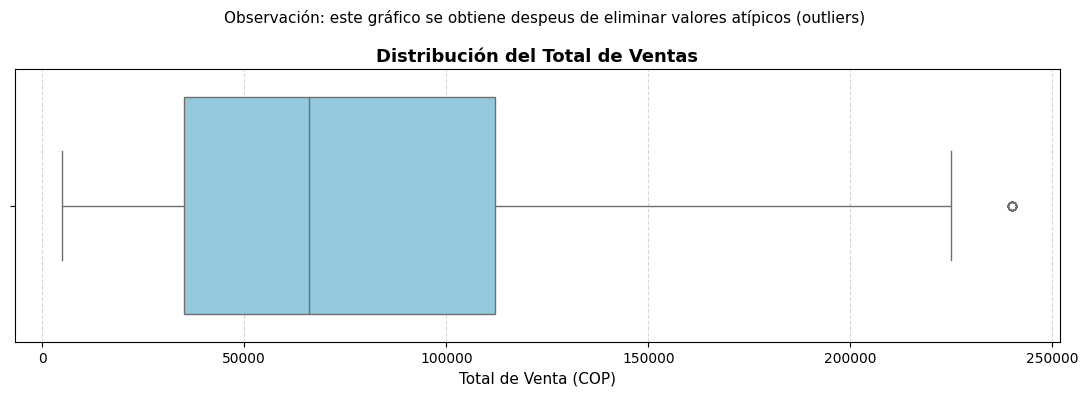

In [158]:
plt.figure(figsize=(11,4))

sns.boxplot(
    x=df['Total_Venta'],
    color='skyblue'
)

plt.title(
    "Distribución del Total de Ventas",
    fontsize=13,
    fontweight='bold'
)

plt.suptitle(
    "Observación: este gráfico se obtiene despeus de eliminar valores atípicos (outliers)",
    fontsize=11,
    y=0.98
)

plt.xlabel("Total de Venta (COP)", fontsize=11)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

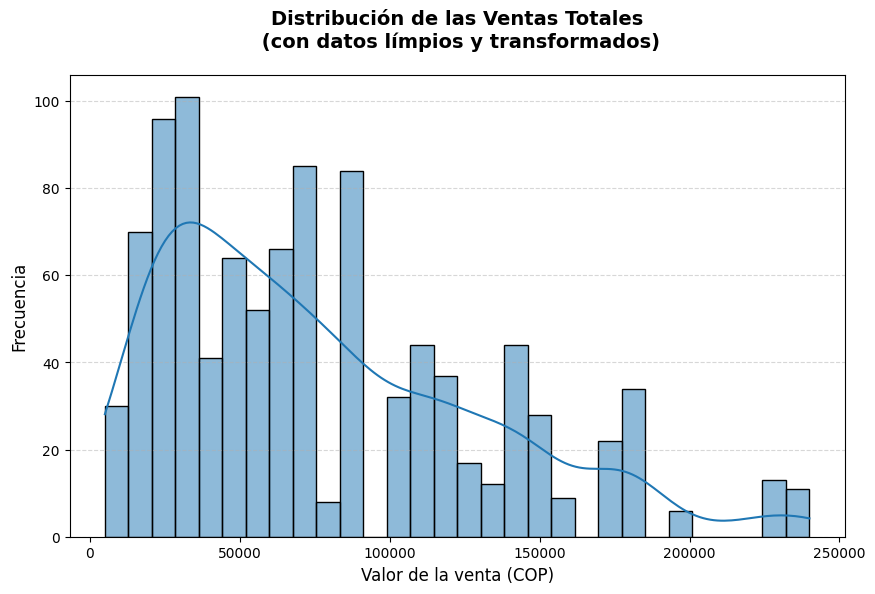

In [159]:
# Histograma ventas totales con datos limpios y transformados
ig, ax = plt.subplots(figsize=(10,6))

sns.histplot(df['Total_Venta'], bins=30, kde=True, ax=ax)

ax.set_title(
    "Distribución de las Ventas Totales\n (con datos límpios y transformados)",
    fontsize=14,
    fontweight='bold',
    pad=20
)

ax.set_xlabel("Valor de la venta (COP)", fontsize=12)
ax.set_ylabel("Frecuencia", fontsize=12)

ax.grid(axis='y', linestyle='--', alpha=0.5)

fig.tight_layout()
fig.subplots_adjust(top=0.90)

plt.show()

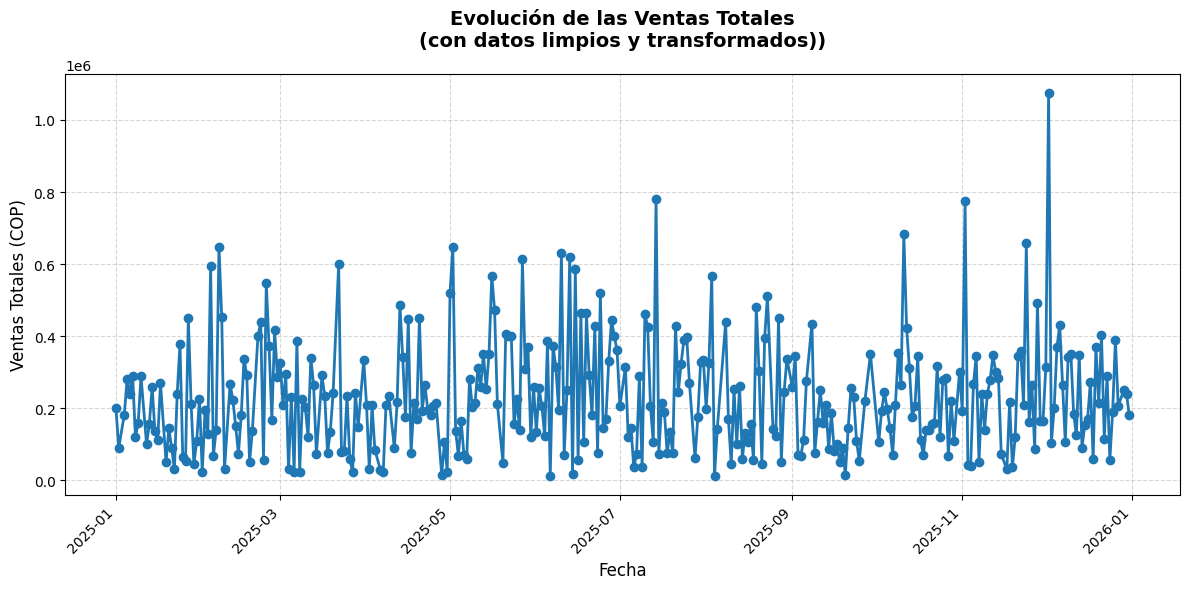

In [160]:
# Agrupar las ventas por fecha
ventas = df.groupby('Fecha')['Total_Venta'].sum()

# Crear la figura
plt.figure(figsize=(12,6))

# Graficar la evolución de las ventas
ventas.plot(marker='o', linewidth=2)

# Título del gráfico
plt.title(
    "Evolución de las Ventas Totales\n(con datos limpios y transformados))",
    fontsize=14,
    fontweight='bold',
    pad=20
)

# Títulos de los ejes
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Ventas Totales (COP)", fontsize=12)

# Mejorar la visualización
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)

# Ajustar márgenes
plt.tight_layout()

plt.show()

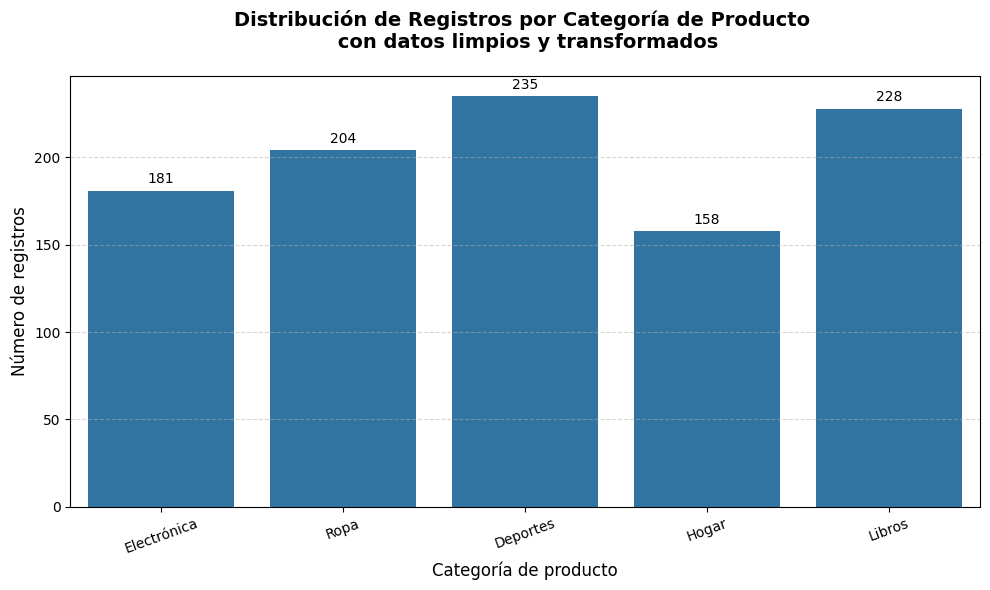

In [161]:
# Gráfico de barras de la distribución por categoría
plt.figure(figsize=(10, 6))

# Asignamos el gráfico a la variable 'ax'
ax = sns.countplot(data=df, x='Categoría')

plt.title(
    "Distribución de Registros por Categoría de Producto \n con datos limpios y transformados",
    fontsize=14,
    fontweight='bold',
    pad=20
)

plt.xlabel("Categoría de producto", fontsize=12)
plt.ylabel("Número de registros", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=20)

# --- NUEVA LÍNEA: Coloca los valores sobre las barras ---
# padding=3 separa un poco el texto de la barra, fmt='%d' asegura que sean números enteros
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fmt='%d')

plt.tight_layout()
plt.show()

# **6. Conclusiones**

## **6.1 Proceso metodológico aplicado**

El análisis aquí aplicado inició con la carga y exploración del conjunto de datos para conocer su estructura y contenido con el fin de evaluar su calidad. Después se hizo una etapa de limpieza y transformación en la que se trataron valores nulos, registros duplicados, valores negativos, valores atípicos y se verificó la consistencia de los datos mediante reglas de validación. Finalmente, se calcularon indicadores estadísticos y se elaboraron visualizaciones que permitieron interpretar el comportamiento de las ventas sobre el conjunto de datos limpios y transformados.

---

## **6.2 Naturaleza de los datos**

El conjunto de datos corresponde a un registro de ventas realizadas durante el año 2025 e incluye información relacionada con la fecha de la venta, la categoría y el producto comercializado, la cantidad vendida, el precio unitario y el valor total de cada transacción. Estas variables permiten analizar tanto el volumen de ventas como el comportamiento económico de cada categoría de productos.

---

## **6.3 Hallazgos en los datos originales**

La exploración inicial permitió identificar diversos problemas de calidad que podían afectar la confiabilidad del análisis; tale como valores nulos, registros duplicados, valores negativos y un valor atípico extremo asociado al precio unitario, cuyo comportamiento difería considerablemente del resto de los registros y podía distorsionar las medidas estadísticas.

También se comprobó que la distribución inicial de las ventas presentaba una alta influencia de estos valores extremos, razón por la cual resultó necesario realizar un proceso de depuración antes de interpretar los resultados.

---

## **6.4 Hallazgos durante la limpieza y transformación**

Las actividades de limpieza permitieron obtener un conjunto de datos más consistente y representativo del comportamiento real de las ventas. La eliminación de los valores atípicos redujo la influencia de registros anómalos sobre el promedio y la dispersión de los datos, mientras que la conversión de la variable **Fecha** facilitó el análisis temporal.

Adicionalmente, la validación entre las variables **Cantidad**, **Precio_Unitario** y **Total_Venta** confirmó que los registros conservados cumplen la relación matemática esperada (regla de negocio), lo que proporciona mayor confianza en los resultados obtenidos durante el análisis.

---

## **6.5 Principales resultados del análisis**

Los indicadores obtenidos muestran que la distribución de las ventas depende de factores la cantidad de productos comercializados y del precio promedio de cada categoría. En este sentido, aunque **Deportes** registró la mayor cantidad de unidades vendidas (716), la categoría **Electrónica** concentró la mayor participación en las ventas totales (22,96 %), seguida por **Hogar** (22,45 %). Esto evidencia que categorías con un menor volumen de unidades pueden generar mayores ingresos cuando comercializan productos de mayor valor.

El análisis del precio unitario promedio confirma este comportamiento, ya que la categoría **Hogar** presentó el mayor precio promedio ($51.822,78), mientras que **Libros** y **Deportes** registraron los menores valores promedio.

Las ventas mantuvieron una dinámica relativamente estable durante el año mostrando incrementos en los meses de **mayo** y **junio** y en **septiembre** se presentó el menor volumen de ventas. Otro dato relevante es que **2 de diciembre de 2025** correspondió al día con el mayor valor de ventas.

Los gráficos estadísticos facilitaron complementar los resultados obtenidos; en ellos, por ejemplo, se pudo mostrar una distribución de las ventas más homogénea después del tratamiento de los valores atípicos. También facilitaron la identificación de patrones tanto en la evolución temporal como en la distribución de las categorías.

---

## **6.6 Conclusión general**

Mediante el proceso de análisis, limpieza y transformación se pudo mejorar la calidad del conjunto de datos original en una fuente de información consistente y confiable para el análisis estadístico. Los resultados evidencian que las categorías con mayor número de unidades vendidas no necesariamente generan los mayores ingresos, estos e debe a que el precio promedio de los productos influye de manera significativa en el valor total de las ventas.

De igual forma, el análisis temporal permitió identificar meses y fechas con un comportamiento comercial superior al promedio, información que puede ser utilizada para apoyar procesos de planeación, abastecimiento y definición de estrategias comerciales.



## **7. Créditos**
## Nombre de la actividad: _El código secreto de los datos, desvelando misterios con Python._

---

#### Ramírez Valbuena Ismael

#### Sarmiento Otalora Diego Alejandro

#### Solórzano Benavidez Juan Carlos

---

**Profesor:**

Otoniel Humberto Castañeda Rodríguez

---

Programación para Analítica de Datos

Maestría en Analítica de Datos

Universidad Central

                         2026